Plan Creation Dev

In [210]:
import pandas as pd
from pydantic import BaseModel, Field
from dataclasses import dataclass, field
from typing import List, Optional, Literal, Dict
from datetime import date, timedelta

In [211]:
from langchain.chat_models import init_chat_model
import os 
from dotenv import load_dotenv
load_dotenv()

default_model_name = "gpt-4o-mini"

def get_llm():
    if not os.getenv("OPENAI_API_KEY"):
        raise ValueError("OPENAI_API_KEY is not configured.")

    return init_chat_model(
        model=default_model_name,
        temperature=0,
        api_key=os.getenv("OPENAI_API_KEY"),
        max_tokens=1024,
    )

llm = get_llm()



data classes

In [212]:
@dataclass
class Workout:
    id: str                  # Unique ID (e.g., "run_long_01")
    discipline: str          # "swim", "bike", "run"
    category: str            # "long", "interval", "recovery", "brick"
    duration_minutes: int
    intensity: str           # "low", "moderate", "high"

@dataclass
class TrainingDay:
    date: date
    day_name: str            # "Monday", "Tuesday"
    is_rest_day: bool
    workouts: List[Workout] = field(default_factory=list)

@dataclass
class TrainingWeek:
    week_number: int
    phase: str               # "Base", "Build", "Peak", "Taper"
    total_volume_minutes: int
    focus: str               # e.g., "Aerobic Endurance"
    # load_type: Optional[str]        # e.g., "Recover", "Build", "Peak"
    days: List[TrainingDay] = field(default_factory=list)
    workouts: List[str] = field(default_factory=list)  # Added for demo purposes

@dataclass
class TriathlonPlan:
    name: str
    user_level: str
    total_weeks: int
    weeks: List[TrainingWeek] = field(default_factory=list)

@dataclass
class SchedulerConfig:
    # Anchor Days (Fixed)
    long_run_day: str           # e.g. "Sunday"
    long_bike_day: str          # e.g. "Saturday"
    
    # Constraints
    pool_access_days: List[str] # e.g. ["Tuesday", "Thursday", "Friday"]
    training_days: List[str]    # Days the user is willing to train e.g. ["Mon", "Tue", "Thu", "Sat", "Sun"]
    
    # Capacity
    allow_doubles: bool = False
    max_doubles_per_week: int = 0

class WorkoutStep(BaseModel):
    segment: Literal["Warm Up", "Main Set", "Cool Down", "Rest"]
    duration: str = Field(..., description="Human readable duration e.g. '10 min' or '4x100m'")
    description: str = Field(..., description="Specific instruction e.g. '@ 70% effort', 'Build to Z4'")
    zone: str = Field(..., description="Target Zone (Z1-Z5)")

class DetailedSession(BaseModel):
    workout_id: str = Field(..., description="The exact ID passed in the prompt for this workout")
    coach_notes: str = Field(..., description="A short motivational note or focus tip.")
    main_set_steps: List[WorkoutStep] = Field(..., description="Only the main set intervals.")
    progression_summary: str = Field(..., description="A short summary of the main set (e.g. '5x1km @ Threshold') to save for next week's context.")

class WeeklyBatchResponse(BaseModel):
    sessions: List[DetailedSession] = Field(..., description="List of detailed sessions for the week.")

config

In [213]:
DISTANCE_CONFIG = {
    "sprint": { "allowed_sessions": [3, 4, 5, 6, 7], "min_weeks": 6, "max_weeks": 20, "taper_weeks": 1, "long_run_max_minutes": 75, "long_bike_max_minutes": 120 },
    "olympic": { "allowed_sessions": [4, 5, 6, 7, 8], "min_weeks": 8, "max_weeks": 24, "taper_weeks": 2, "long_run_max_minutes": 100, "long_bike_max_minutes": 180 },
    "half": { "allowed_sessions": [5, 6, 7, 8, 9, 10], "min_weeks": 10, "max_weeks": 28, "taper_weeks": 2, "long_run_max_minutes": 130, "long_bike_max_minutes": 240 },
    "full": { "allowed_sessions": [6, 7, 8, 9, 10, 11, 12], "min_weeks": 16, "max_weeks": 32, "taper_weeks": 3, "long_run_max_minutes": 180, "long_bike_max_minutes": 360 }
}

WORKOUT_TYPES = {
  "swim": {
    "S_TECH": { "name": "Technique Drill", "intensity": "recovery", "desc": "Focus on form, drills, short dist." },
    "S_ENDURANCE": { "name": "Endurance Swim", "intensity": "aerobic", "desc": "Continuous swimming, moderate effort." },
    "S_CSS": { "name": "CSS Threshold", "intensity": "hard", "desc": "Intervals at Critical Swim Speed." },
    "S_SPEED": { "name": "Speed/Sprint", "intensity": "very_hard", "desc": "Short, max effort sprints." }
  },
  "bike": {
    "B_LONG": { "name": "Long Ride", "intensity": "aerobic", "desc": "Zone 2, duration focus." },
    "B_AEROBIC": { "name": "Aerobic Maintenance", "intensity": "support", "desc": "Standard Z2 ride." },
    "B_SWEETSPOT": { "name": "Sweet Spot", "intensity": "hard", "desc": "Intervals at 88-93% FTP." },
    "B_VO2": { "name": "VO2 Max", "intensity": "very_hard", "desc": "Intervals > 105% FTP." },
    "B_THRESH": { "name": "Threshold", "intensity": "hard", "desc": "Intervals at 100% FTP." },
    "B_RECOVERY": { "name": "Spin Out", "intensity": "recovery", "desc": "Z1 active recovery." }
  },
  "run": {
    "R_LONG": { "name": "Long Run", "intensity": "aerobic", "desc": "Z2, time on feet." },
    "R_BASE": { "name": "Base Run", "intensity": "support", "desc": "Short, easy aerobic run." },
    "R_TEMPO": { "name": "Tempo Run", "intensity": "hard", "desc": "Sustained Z3 effort." },
    "R_HILLS": { "name": "Hill Reps", "intensity": "hard", "desc": "Strength endurance on inclines." },
    "R_INTERVAL": { "name": "Speedwork", "intensity": "very_hard", "desc": "Track or fast intervals." },
    }
}

PHASE_FOCUS = {
  "base": {
    "swim": { "order": ["S_TECH", "S_CSS", "S_ENDURANCE"], "filler": "S_TECH" },
    "bike": { "order": ["B_LONG", "B_SWEETSPOT", "B_AEROBIC"], "filler": "B_AEROBIC" },
    "run":  { "order": ["R_LONG", "R_HILLS", "R_BASE"], "filler": "R_BASE" }
  },
  "build": {
    "swim": { "order": ["S_ENDURANCE", "S_SPEED", "S_CSS"], "filler": "S_TECH" },
    "bike": { "order": ["B_LONG", "B_VO2", "B_THRESH"], "filler": "B_AEROBIC" },
    "run":  { "order": ["R_LONG", "R_INTERVAL", "R_TEMPO"], "filler": "R_BASE" }
  },
  "peak": {
    "swim": { "order": ["S_ENDURANCE", "S_CSS", "S_SPEED"], "filler": "S_TECH" },
    "bike": { "order": ["B_LONG", "B_THRESH", "B_AEROBIC"], "filler": "B_RECOVERY" },
    "run":  { "order": ["R_LONG", "R_TEMPO", "R_BASE"], "filler": "R_BASE" }
  },
  "taper": {
    # Week before race week: Keep intensity (intervals), drop the long endurance stuff
    "swim": { "order": ["S_TAPER", "S_SPEED", "S_ENDURANCE"], "filler": "S_TECH" },
    "bike": { "order": ["B_TAPER", "B_THRESH", "B_AEROBIC"], "filler": "B_RECOVERY" },
    "run":  { "order": ["R_TAPER", "R_INTERVAL", "R_BASE"], "filler": "R_BASE" }
  },
  "race_week": {
    # The final 7 days: Specific openers and shakeouts only
    "swim": { "order": ["S_RACE_PREP", "S_TECH"], "filler": "S_TECH" },
    "bike": { "order": ["B_RACE_PREP", "B_RECOVERY"], "filler": "B_RECOVERY" },
    "run":  { "order": ["R_SHAKEOUT", "R_BASE"], "filler": "R_SHAKEOUT" }
  }
}

SESSION_DISTRIBUTION = {
    3: (1, 1, 1),
    4: (1, 2, 1), # Bike bias
    5: (1, 2, 2),
    6: (2, 2, 2), # Balanced
    7: (2, 3, 2), # Bike focus
    8: (3, 3, 2),
    9: (3, 3, 3),
    10: (3, 4, 3)
}

VOLUME_GUIDELINES = {
    "sprint": {
        "beginner": (180, 300), "intermediate": (240, 420), "advanced": (300, 540)
    },
    "olympic": {
        "beginner": (240, 420), "intermediate": (360, 600), "advanced": (480, 720)
    },
    "half": {
        "beginner": (360, 600), "intermediate": (480, 720), "advanced": (600, 900)
    },
    "full": {
        "beginner": (480, 840), "intermediate": (600, 960), "advanced": (720, 1200)
    }
}

DISCIPLINE_SPLIT = { "swim": 0.20, "bike": 0.50, "run":  0.30 }

# How much weight each session type gets relative to others
SESSION_CONSTRAINTS = {
    "sprint": {
        "taper_weeks": 1,
        "run":  { "ramp": (30, 60),   "cap": 75,  "max_ratio": 0.30 },
        "bike": { "ramp": (60, 90),   "cap": 120, "max_ratio": 0.45 },
        "swim": { "ramp": (30, 45),   "cap": 60,  "max_ratio": 0.25 }
    },
    "olympic": {
        "taper_weeks": 2,
        "run":  { "ramp": (45, 90),   "cap": 105, "max_ratio": 0.30 },
        "bike": { "ramp": (90, 150),  "cap": 180, "max_ratio": 0.50 },
        "swim": { "ramp": (45, 60),   "cap": 75,  "max_ratio": 0.25 }
    },
    "half": {
        "taper_weeks": 2,
        "run":  { "ramp": (60, 135),  "cap": 150, "max_ratio": 0.35 },
        "bike": { "ramp": (120, 240), "cap": 270, "max_ratio": 0.50 },
        "swim": { "ramp": (45, 80),   "cap": 90,  "max_ratio": 0.20 }
    },
    "full": {
        "taper_weeks": 3,
        "run":  { "ramp": (90, 150),  "cap": 180, "max_ratio": 0.30 },
        "bike": { "ramp": (180, 330), "cap": 360, "max_ratio": 0.55 },
        "swim": { "ramp": (60, 90),   "cap": 105, "max_ratio": 0.15 }
    }
}


Scheduling Class

In [214]:
   
class WeeklyScheduler:
    def __init__(self, config: SchedulerConfig):
        self.cfg = config
        self.days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

    def schedule(self, week_obj: TrainingWeek, workouts: List[Workout]) -> TrainingWeek:
        """
        Main entry point. Maps a list of workouts to specific days based on config.
        """
        # 1. Initialize Empty Week (Mark Rest Days)
        week_map = self._init_week_map()
        
        # 2. Sort Workouts by Scheduling Difficulty
        # (Anchors First -> Swims -> Others)
        workouts.sort(key=self._get_priority, reverse=True)

        # 3. Placement Loop
        doubles_used = 0
        
        for workout in workouts:
            placed = False
            
            # --- STRATEGY 1: Fixed Anchors ---
            if self._is_anchor(workout):
                target_day = self._get_anchor_target(workout)
                # Force placement (overrides rest day preference if necessary)
                self._place_workout(week_map, target_day, workout, force=True)
                placed = True
                
            # --- STRATEGY 2: Variable Placement ---
            else:
                # Get valid candidates based on constraints
                candidate_days = self._get_candidate_days(workout, week_map)
                
                # Sub-strategy A: Find an EMPTY slot first
                for day in candidate_days:
                    if len(week_map[day].workouts) == 0:
                        self._place_workout(week_map, day, workout)
                        placed = True
                        break
                
                # Sub-strategy B: Find a DOUBLE slot (if allowed)
                if not placed and self.cfg.allow_doubles and doubles_used < self.cfg.max_doubles_per_week:
                    for day in candidate_days:
                        if self._can_double_up(week_map[day], workout):
                            self._place_workout(week_map, day, workout)
                            doubles_used += 1
                            placed = True
                            break

            if not placed:
                print(f"WARNING: Could not schedule {workout.id} ({workout.discipline}). Constraints too tight.")

        for day_name in self.days_order:
            day_obj = week_map[day_name]
            # True if empty, False if has workouts
            day_obj.is_rest_day = (len(day_obj.workouts) == 0)

        # 4. Finalize
        week_obj.days = list(week_map.values())
        return week_obj

    # -------------------------------------------------------------------------
    # Helper Logic
    # -------------------------------------------------------------------------

    def _init_week_map(self) -> Dict[str, TrainingDay]:
        """Creates the 7-day bucket, marking days as Rest based on user input."""
        week_map = {}
        for d in self.days_order:
            # If day is NOT in user's training_days list, it's a rest day.            
            week_map[d] = TrainingDay(
                date=date.today(), # Placeholder
                day_name=d,
                is_rest_day=False,
                workouts=[]
            )
        return week_map

    def _get_priority(self, w: Workout) -> int:
        """Higher number = Needs to be scheduled earlier."""
        if self._is_anchor(w): return 3   # Highest: Fixed day
        if w.discipline == "swim": return 2 # Medium: Pool constraint
        return 1                          # Low: Flexible

    def _is_anchor(self, w: Workout) -> bool:
        """Checks if workout is a Long Run or Long Bike."""
        return "LONG" in w.id

    def _get_anchor_target(self, w: Workout) -> str:
        if w.discipline == "run": return self.cfg.long_run_day
        if w.discipline == "bike": return self.cfg.long_bike_day
        return "Monday" # Should not happen

    def _get_candidate_days(self, w: Workout, week_map: Dict) -> List[str]:
        """Returns list of day names where this workout is ALLOWED to go."""
        candidates = []
        
        # 1. Filter by Pool Access
        possible_days = self.days_order
        if w.discipline == "swim":
            possible_days = [d for d in possible_days if d in self.cfg.pool_access_days]
            
        # 2. Filter by Rest Days (User Preference)
        # Note: We already handled Anchors, so here we respect rest days.
        for day in possible_days:
            if day in self.cfg.training_days:
                candidates.append(day)
                
        return candidates

    def _can_double_up(self, day_obj: TrainingDay, new_workout: Workout) -> bool:
        """Rules for valid double days."""
        current_load = len(day_obj.workouts)
        
        # Rule 1: Slot must exist (0 or 1 sessions currently)
        if current_load >= 2:
            return False
            
        # Rule 2: Don't double the same discipline (e.g. No Run + Run)
        # (Unless you want to allow that, but usually it's distinct sports)
        for existing in day_obj.workouts:
            if existing.discipline == new_workout.discipline:
                return False
                
        return True

    def _place_workout(self, week_map, day_name, workout, force=False):
        """Actually appends the workout to the day."""
        day_obj = week_map[day_name]
        
        # If forcing (Anchor), we define it as NOT a rest day anymore
        if force and day_obj.is_rest_day:
            day_obj.is_rest_day = False
            
        day_obj.workouts.append(workout)


Volumn Manager

In [215]:
class VolumeManager:
    def __init__(self, user_inputs: dict):
        self.level = user_inputs.get("user_level", "intermediate").lower()
        self.distance = user_inputs.get("distance", "half").lower()
        self.total_weeks = user_inputs["total_weeks"]
        
        # Load Configs
        guidelines = VOLUME_GUIDELINES.get(self.distance, {}).get(self.level, (240, 480))
        self.start_min = guidelines[0]
        self.peak_min = guidelines[1]
        
        self.constraints = SESSION_CONSTRAINTS.get(self.distance, SESSION_CONSTRAINTS["half"])
        self.taper_weeks = self.constraints.get("taper_weeks", 2)
        self.peak_week_num = self.total_weeks - self.taper_weeks

    def apply_volume(self, week):
        # 1. Calculate Load & Determine Type
        weekly_total_min, load_type = self._calculate_load(week.week_number)
        
        # 2. Tag the week (Source of Truth for Display)
        week.total_volume_minutes = int(weekly_total_min)
        week.load_type = load_type 

        # 3. Standard Distribution...
        splits = DISCIPLINE_SPLIT  
        vol_swim = int(weekly_total_min * splits["swim"])
        vol_bike = int(weekly_total_min * splits["bike"])
        vol_run  = int(weekly_total_min * splits["run"])

        self._fill_discipline_bucket(week, "swim", vol_swim)
        self._fill_discipline_bucket(week, "bike", vol_bike)
        self._fill_discipline_bucket(week, "run",  vol_run)

    def _calculate_load(self, week_num):
        """
        Returns tuple: (minutes, load_type)
        """
        # A. RACE & TAPER
        weeks_remaining = self.total_weeks - week_num
        
        if weeks_remaining == 0: 
            return self.peak_min * 0.40, "Race Week"
            
        if weeks_remaining < self.taper_weeks:
            taper_progress = (self.taper_weeks - weeks_remaining) / self.taper_weeks
            drop_factor = 0.85 - (0.25 * taper_progress)
            return self.peak_min * drop_factor, "Taper"

        # B. CALCULATE BASE LINEAR LOAD
        # We only apply "Periodization" (Ups and Downs) during the Ramp.
        # Before the ramp (Base Hold), it's steady.
        effective_start_week = max(1, self.peak_week_num - 16)
        
        # --- PHASE 1: BASE HOLD (Steady) ---
        if week_num < effective_start_week:
            # No recovery weeks here. Just steady work.
            return self.start_min, "Base Hold"

        # --- PHASE 2: ACTIVE RAMP (Sawtooth) ---
        # Calculate the Linear point
        ramp_duration = self.peak_week_num - effective_start_week
        current_pos = week_num - effective_start_week
        prog_pct = current_pos / max(1, ramp_duration)
        linear_load = self.start_min + ((self.peak_min - self.start_min) * prog_pct)

        # Apply Reverse Sync ONLY in this phase
        weeks_until_taper = self.peak_week_num - week_num
        
        if weeks_until_taper > 0 and weeks_until_taper % 4 == 0:
            return linear_load * 0.70, "Recover"
            
        if weeks_until_taper > 0 and (weeks_until_taper - 1) % 4 == 0:
            return linear_load * 1.05, "Overreach"
            
        return linear_load, "Build"

    def _fill_discipline_bucket(self, week, discipline, total_minutes):
        # (Same bucket logic as previous version...)
        workouts = [w for w in week.workouts if w.discipline == discipline]
        if not workouts: return

        keys = [w for w in workouts if any(k in w.id for k in ['LONG', 'THRESH', 'CSS', 'SWEETSPOT'])]
        support = [w for w in workouts if w not in keys]
        
        rem_mins = total_minutes
        
        for w in keys:
            if "LONG" in w.id:
                # Pass the load_type so the Ramp Calculator knows if it's a recovery week
                dur = self._get_ramp_duration(week.week_number, discipline, week.load_type)
            else:
                dur = self._get_interval_duration(w.id, discipline, total_minutes)
            w.duration_minutes = dur
            rem_mins -= dur
            
        if support:
            avg_duration = max(30, rem_mins / len(support))
            for w in support:
                w.duration_minutes = 5 * round(avg_duration / 5)

    def _get_ramp_duration(self, week_num, discipline, load_type):
        """
        Calculates Key Session duration, respecting the Phase logic.
        """
        config = self.constraints.get(discipline, {"ramp": (60, 90), "cap": 90})
        start_m, peak_m = config["ramp"]
        hard_cap = config["cap"]

        # 1. Ramp Calculation (Same as before)
        effective_start_week = max(1, self.peak_week_num - 16)
        
        if week_num < effective_start_week:
            base_dur = start_m
        elif week_num >= self.peak_week_num:
            base_dur = peak_m
        else:
            ramp_duration = self.peak_week_num - effective_start_week
            current_pos = week_num - effective_start_week
            prog = current_pos / max(1, ramp_duration)
            base_dur = start_m + ((peak_m - start_m) * prog)

        # 2. Modifiers based on load_type tag
        if load_type == "Race Week": base_dur *= 0.40
        elif load_type == "Taper": base_dur *= 0.75
        elif load_type == "Recover": base_dur *= 0.75 # Drop long run in recovery week
        
        final_dur = 5 * round(base_dur / 5)
        return min(final_dur, hard_cap)

    def _get_interval_duration(self, workout_id, discipline, total_weekly_vol):
        # (Same as previous version)
        limits = self.constraints.get(discipline, {"max_mins": 60, "cap": 90})
        target = total_weekly_vol * 0.20
        interval_cap = limits["cap"] * 0.65 
        return max(45, min(interval_cap, 5 * round(target / 5)))

Plan Generator Class

In [216]:
class TriathlonPlanGenerator:
    def __init__(self, input_data: dict, scheduler_config: SchedulerConfig):
        self.input = input_data
        self.scheduler = WeeklyScheduler(scheduler_config)
        self.volume_manager = VolumeManager(input_data)
        self.total_weeks = input_data["total_weeks"]
        self.distance = input_data["distance"]
        self.base_sessions = self._get_base_distribution()
        self.phase_schedule = self._assign_phases()

    def build(self) -> TriathlonPlan:
        plan = TriathlonPlan(
            name=self.input["plan_name"],
            user_level=self.input.get("user_level", "Intermediate"),
            total_weeks=self.total_weeks
        )

        for week_num in range(1, self.total_weeks + 1):
            week_obj = self._create_week(week_num)
            plan.weeks.append(week_obj)
            
        return plan

    def _create_week(self, week_num: int) -> TrainingWeek:
        phase_name = self.phase_schedule[week_num]
        is_race_week = (week_num == self.total_weeks)
        logic_phase = "race_week" if is_race_week else phase_name
        
        counts = {
            "swim": self._adjust_volume(self.base_sessions["swim"], is_race_week),
            "bike": self._adjust_volume(self.base_sessions["bike"], is_race_week),
            "run":  self._adjust_volume(self.base_sessions["run"],  is_race_week)
        }

        # 1. Generate the Workout Objects
        workouts = []
        workouts.extend(self._get_slots("swim", counts["swim"], logic_phase))
        workouts.extend(self._get_slots("bike", counts["bike"], logic_phase))
        workouts.extend(self._get_slots("run",  counts["run"],  logic_phase))

        # 2. Create Skeleton Week
        week_obj = TrainingWeek(
            week_number=week_num,
            phase=phase_name,
            total_volume_minutes=0, 
            focus="Race Prep" if is_race_week else phase_name,
            days=[], 
            workouts=workouts # Store raw list for debugging
        )

        # Apply Volume Management
        self.volume_manager.apply_volume(week_obj)

        # 3. Schedule them into Days
        finalized_week = self.scheduler.schedule(week_obj, workouts)
        
        return finalized_week

    def _get_slots(self, discipline: str, count: int, phase: str) -> List[Workout]:
        rules = PHASE_FOCUS.get(phase.lower(), {}).get(discipline, {})
        priority_order = rules.get("order", [])
        filler = rules.get("filler", f"{discipline[0].upper()}_RECOVERY")
        
        selected_sessions = []
        for i in range(count):
            s_id = priority_order[i] if i < len(priority_order) else filler
            details = WORKOUT_TYPES[discipline].get(s_id, {})
            wk = Workout(
                id=s_id,
                discipline=discipline,
                category=details.get("intensity", "aerobic"),
                duration_minutes=0,
                intensity=details.get("intensity", "aerobic")
            )
            selected_sessions.append(wk)
        return selected_sessions

    def _adjust_volume(self, base_count: int, is_race_week: bool) -> int:
        if is_race_week: return max(1, base_count - 1)
        return base_count

    def _assign_phases(self) -> Dict[int, str]:
        phases = {}
        taper_len = DISTANCE_CONFIG[self.distance.lower()]["taper_weeks"]
        peak_len = 2 if self.total_weeks < 12 else 3
        remaining = self.total_weeks - taper_len - peak_len
        
        if remaining < 4:
            build_len = remaining
            base_len = 0
        else:
            build_len = int(remaining * 0.6)
            base_len = remaining - build_len

        current_week = 1
        for _ in range(base_len): phases[current_week] = "Base"; current_week += 1
        for _ in range(build_len): phases[current_week] = "Build"; current_week += 1
        for _ in range(peak_len): phases[current_week] = "Peak"; current_week += 1
        for _ in range(taper_len): phases[current_week] = "Taper"; current_week += 1
        return phases

    def _get_base_distribution(self) -> Dict[str, int]:
        total = self.input["total_sessions_available"]
        dist = SESSION_DISTRIBUTION.get(total, (2, 2, 2))
        return {"swim": dist[0], "bike": dist[1], "run": dist[2]}

In [217]:
class ProgressionState:
    def __init__(self):
        # Maps "WORKOUT_TYPE_ID" -> "Last Main Set Summary"
        # e.g. {"B_SWEETSPOT": "3x8min @ 88%", "R_INTERVAL": "10x400m"}
        self.history = {}

    def get_context(self, type_id: str) -> str:
        return self.history.get(type_id, None)

    def update(self, type_id: str, summary: str):
        self.history[type_id] = summary
        
    def reset(self):
        self.history = {}

In [218]:
class BatchWorkoutGenerator:
    def __init__(self, llm_model, workout_types, phase_config):
        self.llm = llm_model.with_structured_output(WeeklyBatchResponse)
        self.types = workout_types
        self.phases = phase_config
        self.tracker = ProgressionState()
        
        # Define which sessions are "Key" (Worth spending LLM tokens on)
        self.key_sessions = [
            "S_CSS", "S_SPEED", 
            "B_SWEETSPOT", "B_VO2", "B_THRESH", "B_CLIMB",
            "R_TEMPO", "R_HILLS", "R_INTERVAL"
        ]

    def process_plan(self, plan: TriathlonPlan):
        print(f"⚡ Generatng detailed workouts for {plan.name}...")
        
        for week in plan.weeks:
            # 1. Identify Workouts
            week_payload = []
            
            # Reset progression logic on phase change? (Optional - here we keep it rolling)
            # if week.week_number == 1: self.tracker.reset()

            for day in week.days:
                if day.is_rest_day or not day.workouts:
                    continue
                
                for workout in day.workouts:
                    # Map the generic scheduler object to a specific Type ID (e.g. R_INTERVAL)
                    type_id = self._infer_type_id(workout, week.phase)
                    
                    # Store this ID on the workout object for later reference
                    workout.type_id = type_id 
                    
                    # Calculate Timings (Sandwich Logic)
                    wu, main, cd = self._calc_timings(workout.duration_minutes)
                    workout.timings = {"wu": wu, "main": main, "cd": cd}

                    # Decide: Template or AI?
                    if type_id in self.key_sessions:
                        # Prepare context for batching
                        context = self.tracker.get_context(type_id)
                        week_payload.append({
                            "id": workout.id, # Using the unique ID like 'run_interval_01'
                            "type_id": type_id,
                            "discipline": workout.discipline,
                            "duration_total": workout.duration_minutes,
                            "duration_main": main,
                            "history": context
                        })
                    else:
                        # Apply Static Template immediately
                        day.detailed_session = getattr(day, 'detailed_session', [])
                        day.detailed_session.append(self._create_template(workout, type_id))

            # 2. Batch Call to LLM (if there are key sessions)
            if week_payload:
                print(f"   > Week {week.week_number}: Batching {len(week_payload)} key sessions...")
                batch_results = self._generate_batch(week_payload, week.phase, week.week_number)
                
                # 3. Map results back to days
                self._distribute_results(week, batch_results)

    def _infer_type_id(self, workout: Workout, phase: str) -> str:
        """Guess the WORKOUT_TYPE key based on phase and category."""
        disc = workout.discipline
        cat = workout.category.lower()
        
        # Try to look up in the PHASE_FOCUS map first
        phase_rules = self.phases.get(phase.lower(), {}).get(disc, {})
        order = phase_rules.get("order", [])
        
        # Heuristics
        if "long" in cat: return f"{disc[0].upper()}_LONG"
        if "recovery" in cat: return f"{disc[0].upper()}_TECH" if disc == "swim" else f"{disc[0].upper()}_RECOVERY"
        
        # Intensity mapping
        if disc == "run":
            if "interval" in cat or "very_hard" in cat: return "R_INTERVAL"
            if "tempo" in cat or "hard" in cat: return "R_TEMPO"
            return "R_BASE"
        elif disc == "bike":
            if "interval" in cat or "very_hard" in cat: return "B_VO2"
            if "hard" in cat: return "B_SWEETSPOT"
            return "B_AEROBIC"
        elif disc == "swim":
            if "hard" in cat: return "S_CSS"
            return "S_ENDURANCE"
            
        return "UNKNOWN"

    def _calc_timings(self, total_mins):
        """Standardizes Warmup/Cooldown to ensure math works."""
        if total_mins < 40: return 5, total_mins - 10, 5
        wu = 15 if total_mins >= 60 else 10
        cd = 10 if total_mins >= 60 else 5
        return wu, total_mins - (wu + cd), cd

    def _generate_batch(self, payload: list, phase: str, week_num: int) -> WeeklyBatchResponse:
        
        # Convert payload to a string prompt
        tasks_str = ""
        for item in payload:
            hist_str = f"(Last time: {item['history']})" if item['history'] else "(First session of block)"
            tasks_str += f"""
            - ID: {item['id']}
              Type: {self.types[item['discipline']].get(item['type_id'], {}).get('name', item['type_id'])}
              Main Set Duration: {item['duration_main']} minutes (EXACTLY)
              Context: {hist_str}
            """
            
        prompt = f"""
        Act as an elite Triathlon Coach. Create the MAIN SET details for these sessions in Week {week_num} ({phase} Phase).
        
        Sessions to generate:
        {tasks_str}
        
        Rules:
        1. Only generate the intervals for the 'Main Set'. Warmup/Cooldown is handled separately.
        2. Strict Adherence: The 'Main Set' steps must sum up to the duration provided.
        3. Progression: If context is provided, slightly progress the difficulty (volume or intensity).
        4. Return a list of sessions matching the IDs provided.
        """
        
        try:
            return self.llm.invoke(prompt)
        except Exception as e:
            print(f"LLM Error: {e}")
            return WeeklyBatchResponse(sessions=[])

    def _distribute_results(self, week, batch_response: WeeklyBatchResponse):
        # Create a lookup map
        result_map = {s.workout_id: s for s in batch_response.sessions}
        
        for day in week.days:
            if not day.workouts: continue
            
            # Ensure list exists
            if not hasattr(day, 'detailed_session'): day.detailed_session = []
            
            for w in day.workouts:
                if w.id in result_map:
                    # 1. Get AI Result
                    ai_res = result_map[w.id]
                    
                    # 2. Update Progression Tracker
                    self.tracker.update(w.type_id, ai_res.progression_summary)
                    
                    # 3. Assemble Sandwich (Python WU + AI Main + Python CD)
                    full_steps = []
                    
                    # Warmup
                    full_steps.append(WorkoutStep(
                        segment="Warm Up", 
                        duration=f"{w.timings['wu']} min", 
                        description="Gradual build Z1-Z2", 
                        zone="Z1"
                    ))
                    
                    # Main Set (AI)
                    full_steps.extend(ai_res.main_set_steps)
                    
                    # Cooldown
                    full_steps.append(WorkoutStep(
                        segment="Cool Down", 
                        duration=f"{w.timings['cd']} min", 
                        description="Easy spin/jog", 
                        zone="Z1"
                    ))
                    
                    # 4. Attach
                    day.detailed_session.append(DetailedSession(
                        workout_id=w.id,
                        coach_notes=ai_res.coach_notes,
                        main_set_steps=full_steps,
                        progression_summary=ai_res.progression_summary
                    ))

    def _create_template(self, w: Workout, type_id: str):
        """Zero-cost template for easy sessions."""
        type_def = self.types[w.discipline].get(type_id, {"name": "Aerobic"})
        
        steps = [
            WorkoutStep(segment="Warm Up", duration=f"{w.timings['wu']} min", description="Easy start", zone="Z1"),
            WorkoutStep(segment="Main Set", duration=f"{w.timings['main']} min", description=f"Steady aerobic effort. {type_def.get('desc','')}", zone="Z2"),
            WorkoutStep(segment="Cool Down", duration=f"{w.timings['cd']} min", description="Relax", zone="Z1"),
        ]
        
        return DetailedSession(
            workout_id=w.id,
            coach_notes=f"Focus on form and consistency.",
            main_set_steps=steps,
            progression_summary="Aerobic Maintenance"
        )


Simulation

In [227]:
user_inputs = {
    "plan_name": "Olympic PR Attempt",   
    "distance": "Olympic",
    "total_weeks": 8,
    "total_sessions_available": 6,
    "user_level": "intermediate",
    "long_run": "Wednesday",
    "long_bike": "Saturday",
    "pool_days": ["Tuesday", "Thursday"],
    "train_days": ["Monday", "Tuesday", "Wednesday", "Thursday","Friday", "Saturday"],
    "willing_to_double": True
}

# 2. Create Scheduler Config
scheduler_config = SchedulerConfig(
    long_run_day=user_inputs["long_run"],
    long_bike_day=user_inputs["long_bike"],
    pool_access_days=user_inputs["pool_days"],
    training_days=user_inputs["train_days"],
    allow_doubles=user_inputs["willing_to_double"],
    max_doubles_per_week=2
)

generator = TriathlonPlanGenerator(user_inputs, scheduler_config) 
final_plan = generator.build()


In [230]:
ai_gen = BatchWorkoutGenerator(llm, WORKOUT_TYPES, PHASE_FOCUS)
ai_gen.process_plan(final_plan)

⚡ Generatng detailed workouts for Olympic PR Attempt...
   > Week 1: Batching 3 key sessions...
   > Week 2: Batching 3 key sessions...
   > Week 3: Batching 3 key sessions...
   > Week 4: Batching 3 key sessions...
   > Week 5: Batching 3 key sessions...
   > Week 6: Batching 3 key sessions...
   > Week 7: Batching 3 key sessions...


In [232]:
def print_detailed_week(plan, week_num):
    week = plan.weeks[week_num - 1]
    print(f"=== WEEK {week.week_number} DETAILS ({week.phase}) ===")
    
    for day in week.days:
        if day.is_rest_day:
            continue
            
        print(f"\n📅 {day.day_name} ({day.date})")
        
        if hasattr(day, 'detailed_session'):
            for sess in day.detailed_session:
                # Find the discipline for display context
                print(f"   🏅 {sess.progression_summary} (ID: {sess.workout_id})")
                print(f"      Note: {sess.coach_notes}")
                for step in sess.main_set_steps:
                    print(f"      - [{step.segment[:4]}] {step.duration}: {step.description} ({step.zone})")
                print("")

# Print details for a middle week (e.g., Week 10 in Build Phase)
print_detailed_week(final_plan, 2)
print_detailed_week(final_plan, 3)

=== WEEK 2 DETAILS (Base) ===

📅 Monday (2025-11-28)
   🏅 15 min @ Z3, 15 min @ Z4 alternating. (ID: B_SWEETSPOT)
      Note: Focus on maintaining a steady effort between zones. Keep your cadence high!
      - [Warm] 10 min: Gradual build Z1-Z2 (Z1)
      - [Main] 15 min: @ Z3 effort, steady pace (Z3)
      - [Main] 15 min: @ Z4 effort, push the pace (Z4)
      - [Cool] 5 min: Easy spin/jog (Z1)


📅 Tuesday (2025-11-28)
   🏅 Aerobic Maintenance (ID: S_TECH)
      Note: Focus on form and consistency.
      - [Warm] 5 min: Easy start (Z1)
      - [Main] 20 min: Steady aerobic effort. Focus on form, drills, short dist. (Z2)
      - [Cool] 5 min: Relax (Z1)


📅 Wednesday (2025-11-28)
   🏅 Aerobic Maintenance (ID: R_LONG)
      Note: Focus on form and consistency.
      - [Warm] 10 min: Easy start (Z1)
      - [Main] 25 min: Steady aerobic effort. Short, easy aerobic run. (Z2)
      - [Cool] 5 min: Relax (Z1)


📅 Thursday (2025-11-28)
   🏅 30 min at CSS pace, maintaining speed and form. (ID

In [228]:
# --- HELPER FORMATTING FUNCTIONS ---
def fmt_dur(mins):
    h = mins // 60
    m = mins % 60
    return f"{h}h {m:02d}m"

def get_w(week, pid):
    return next((w for w in week.workouts if pid in w.id), None)

# --- OUTPUT TABLE ---
print(f"PLAN: {final_plan.name}")
print(f"{'Wk':<3} {'Phase':<10} {'Type':<10} {'Total Vol':<10} {'Swim':<8} {'Bike':<8} {'Run':<8} {'Long Run (Wed)':<16} {'Long Bike (Sat)':<16}")
print("-" * 105)

for week in final_plan.weeks:
    # 1. USE THE TAG (No more math guessing)
    cycle = week.load_type 
    
    # Aggregates
    s_vol = sum(w.duration_minutes for w in week.workouts if w.discipline == "swim")
    b_vol = sum(w.duration_minutes for w in week.workouts if w.discipline == "bike")
    r_vol = sum(w.duration_minutes for w in week.workouts if w.discipline == "run")
    
    # Specific Key Sessions
    lr = get_w(week, "R_LONG")
    lb = get_w(week, "B_LONG")
    
    lr_str = f"{fmt_dur(lr.duration_minutes)}" if lr else "-"
    lb_str = f"{fmt_dur(lb.duration_minutes)}" if lb else "-"

    # Formatting
    row_fmt = f"{week.week_number:<3} {week.phase:<10} {cycle:<12} {fmt_dur(week.total_volume_minutes):<10} {fmt_dur(s_vol):<8} {fmt_dur(b_vol):<8} {fmt_dur(r_vol):<8} {lr_str:<16} {lb_str:<16}"
    
    if cycle == "Recover":
        print(f"\033[94m{row_fmt}\033[0m") # Blue text for recovery
    elif cycle in ["Race Week", "Peak"]:
         print(f"\033[92m{row_fmt}\033[0m") # Green text for race/peak
    elif cycle == "Base Hold":
         print(f"\033[90m{row_fmt}\033[0m") # Grey text for base hold
    else:
        print(row_fmt)

PLAN: Olympic PR Attempt
Wk  Phase      Type       Total Vol  Swim     Bike     Run      Long Run (Wed)   Long Bike (Sat) 
---------------------------------------------------------------------------------------------------------
1   Base       Overreach    6h 18m     1h 15m   2h 15m   1h 55m   0h 45m           1h 30m          
2   Base       Recover      4h 45m     1h 15m   2h 00m   1h 25m   0h 40m           1h 15m          
3   Build      Build        7h 36m     1h 30m   3h 50m   2h 15m   1h 05m           1h 55m          
4   Build      Build        8h 24m     1h 40m   4h 10m   2h 30m   1h 10m           2h 05m          
5   Peak       Overreach    9h 39m     1h 55m   3h 20m   2h 55m   1h 20m           2h 20m          
6   Peak       Build        10h 00m    2h 00m   3h 30m   3h 00m   1h 30m           2h 30m          
7   Taper      Taper        7h 15m     1h 30m   3h 35m   2h 10m   -                -               
8   Taper      Race Week    4h 00m     0h 50m   2h 00m   1h 10m   -    

In [221]:
import matplotlib.pyplot as plt
import seaborn as sns # Optional, just makes it look nicer

def plot_plan_volume(plan: TriathlonPlan):
    # 1. Flatten the data
    data = []
    phase_map = {} # Store phases to color the background later
    
    for week in plan.weeks:
        phase_map[week.week_number] = week.phase
        for day in week.days:
            for workout in day.workouts:
                data.append({
                    "Week": week.week_number,
                    "Discipline": workout.discipline.capitalize(),
                    "Duration": workout.duration_minutes
                })

    # 2. Create DataFrame
    df = pd.DataFrame(data)
    
    # Group by Week and Discipline
    df_grouped = df.groupby(["Week", "Discipline"])["Duration"].sum().unstack(fill_value=0)
    
    # Calculate Total for the Line Chart
    df_grouped["Total"] = df_grouped.sum(axis=1)
    
    # Convert to Hours for easier reading
    df_grouped = df_grouped / 60 

    # 3. Setup the Plot
    fig, ax = plt.subplots(1, 1, figsize=(12, 5), sharex=True)
    plt.subplots_adjust(hspace=0.1)

    # --- CHART 1: Stacked Bar (Disciplines) ---
    # We drop 'Total' for the bar chart so it doesn't get plotted as a bar
    colors = {"Swim": "#1f77b4", "Bike": "#ff7f0e", "Run": "#2ca02c"}
    df_grouped.drop(columns=["Total"]).plot(
        kind='bar', 
        stacked=True, 
        ax=ax, 
        color=[colors.get(x, '#333') for x in df_grouped.columns if x != 'Total'],
        edgecolor="white",
        width=0.8
    )
    
    ax.set_ylabel("Hours per Week")
    ax.set_title(f"Volume by Discipline: {plan.name}")
    ax.legend(loc="upper left")
    ax.grid(axis='y', linestyle='--', alpha=0.5)


    # --- FANCY: Add Phase Background Colors ---
    # We iterate through weeks to find phase changes
    # Colors for phases
    phase_colors = {
        "Base": "green", 
        "Build": "orange", 
        "Peak": "red", 
        "Taper": "blue", 
        "Race Week": "gold"
    }
    
    # Logic to draw colored rectangles behind the charts
    # (Simplified for the bar chart x-axis which uses categorical indices 0..N-1)
    # Since Pandas bar plot uses integer indexes 0, 1, 2 for Week 1, 2, 3...
    
    for i, week_num in enumerate(df_grouped.index):
        phase = phase_map[week_num]
        color = phase_colors.get(phase, "white")
        
        ax.axvspan(i - 0.5, i + 0.5, color=color, alpha=0.1, zorder=0)
            
            # Label the phase at the top of the top chart only, and only if it changes
        if i == 0 or phase_map[df_grouped.index[i-1]] != phase:
            ax.text(i, ax.get_ylim()[1]*0.95, phase.upper(), 
                    rotation=90, verticalalignment='top', fontsize=8, fontweight='bold', color='gray')

    plt.show()

In [229]:
from datetime import date
import dataclasses

def print_plan_snapshot(plan: TriathlonPlan):
    print(f"=== PLAN SNAPSHOT: {plan.name} ===")
    print(f"Level: {plan.user_level} | Weeks: {plan.total_weeks}")
    print("=" * 60)

    total_plan_minutes = 0

    for week in plan.weeks:
        print(f"\nWEEK {week.week_number}: {week.phase} Phase ({week.focus})")
        print(f"Target Volume: {week.total_volume_minutes} mins")
        print("-" * 60)
        
        actual_week_minutes = 0
        
        for day in week.days:
            # Format: [Mon] 2023-10-01: 
            day_header = f"[{day.day_name[:3]}] {day.date}:"
            
            if day.is_rest_day or not day.workouts:
                print(f"{day_header:<20} REST DAY")
                continue

            # If there are workouts, list them
            workout_strs = []
            for w in day.workouts:
                actual_week_minutes += w.duration_minutes
                # e.g., Run (Long) - 90m
                w_str = f"{w.discipline.title()} ({w.category}) {w.duration_minutes}m"
                workout_strs.append(w_str)
            
            # Handle double days
            print(f"{day_header:<20} " + " + ".join(workout_strs))
            
        print("-" * 60)
        print(f"  > Week Actual Volume: {actual_week_minutes} mins")
        total_plan_minutes += actual_week_minutes

    print("=" * 60)
    print(f"TOTAL PLAN VOLUME: {total_plan_minutes / 60:.1f} Hours")

# Usage
print_plan_snapshot(final_plan)

=== PLAN SNAPSHOT: Olympic PR Attempt ===
Level: intermediate | Weeks: 8

WEEK 1: Base Phase (Base)
Target Volume: 378 mins
------------------------------------------------------------
[Mon] 2025-11-28:    Bike (hard) 45m
[Tue] 2025-11-28:    Swim (recovery) 30m
[Wed] 2025-11-28:    Run (aerobic) 45m
[Thu] 2025-11-28:    Swim (hard) 45m
[Fri] 2025-11-28:    Run (hard) 70m
[Sat] 2025-11-28:    Bike (aerobic) 90m
[Sun] 2025-11-28:    REST DAY
------------------------------------------------------------
  > Week Actual Volume: 325 mins

WEEK 2: Base Phase (Base)
Target Volume: 285 mins
------------------------------------------------------------
[Mon] 2025-11-28:    Bike (hard) 45m
[Tue] 2025-11-28:    Swim (recovery) 30m
[Wed] 2025-11-28:    Run (aerobic) 40m
[Thu] 2025-11-28:    Swim (hard) 45m
[Fri] 2025-11-28:    Run (hard) 45m
[Sat] 2025-11-28:    Bike (aerobic) 75m
[Sun] 2025-11-28:    REST DAY
------------------------------------------------------------
  > Week Actual Volume: 280 

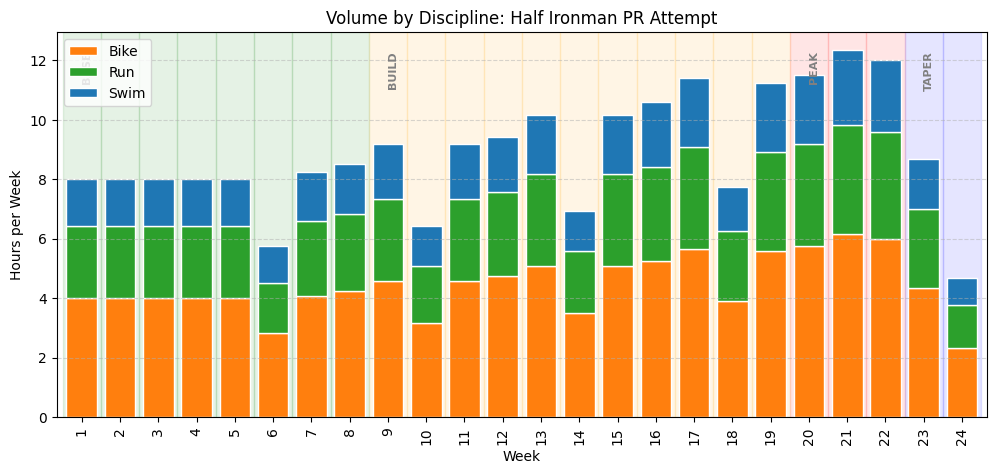

In [223]:
plot_plan_volume(final_plan)